In [69]:
import sys
import importlib
sys.path.insert(0, '/home/lpsha/s154446/fractality/space_filling_model')
import space_filling
importlib.reload(space_filling)
from space_filling import get_geodataframe, run_ensemble, to_geodataframe, run_model
from space_filling import run_model, add_noise_streets, to_geodataframe

import powerlaw

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import random
import matplotlib.colors as mcolors
from itertools import product

sys.path.insert(0, '/home/lpsha/s154446/fractality')
from dgdc import get_dual_dir_con
import momepy
import numpy as np
from tqdm import tqdm

from multiprocessing import Pool, cpu_count
from tqdm import tqdm

from kneed import KneeLocator


plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

In [236]:
def compute_ks(degree,min_range):
    distance = []
    ass = []
    for i_min in min_range:
        fit = powerlaw.Fit(degree,discrete=True,xmin=i_min)
        a = fit.alpha
        xmin = fit.xmin
        x_fit = degree[degree>xmin]
        
        distance.append(fit.power_law.D)
        ass.append(a) 

    return np.array(distance), min_range, ass

def cool_plot(data_df):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    real_degree_sequence=data_df['degree'].values

    d=real_degree_sequence
    d=d[d != 0]
    ks_dist1, xmins1, _ = compute_ks(d, range(1,10))

    ax1 = axes[0]
    ax1.scatter(xmins1,ks_dist1,color='k')
    ax1.plot(xmins1,ks_dist1,color='k')
    ax1.set_xlabel(r'$k_{\min}$')
    ax1.set_ylabel(r'$D_{KS}$')
    ax1.set_title('KS Distance', loc='left')
    ax1.axvline(x=4, color='k', linestyle='--', label=r'$\phi$')

    ax = axes[1]
    y, x = np.histogram(real_degree_sequence, bins=np.logspace(0, np.log10(real_degree_sequence.max()), len(np.unique(real_degree_sequence))), density=True)
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    # ax.scatter(x_nn, y_nn, alpha=1, zorder=1, color='k', s=4)
    ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='red')
    ax.set_ylabel('p(k)')
    ax.set_xlabel('k')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title("Degree Distribution", loc='left')
    ax.axvline(x=4, color='k', linestyle='--', label=r'$\phi$')

    ax.axvline(x=1, color='k', linestyle='--', label=r'$\phi$')

    ax3 = axes[2]
    data_df.plot(ax=ax3, column='degree_log', linewidth=0.5)
    ax3.set_title('Model', loc='left')
    ax3.set_aspect('equal')

    plt.tight_layout()
    plt.show()

    kn = KneeLocator(xmins1,ks_dist1, curve='convex', direction='decreasing')
    print("Knee point:", kn.knee)

# model 1

  Model 1: converged at iteration 2349 with 4706 segments


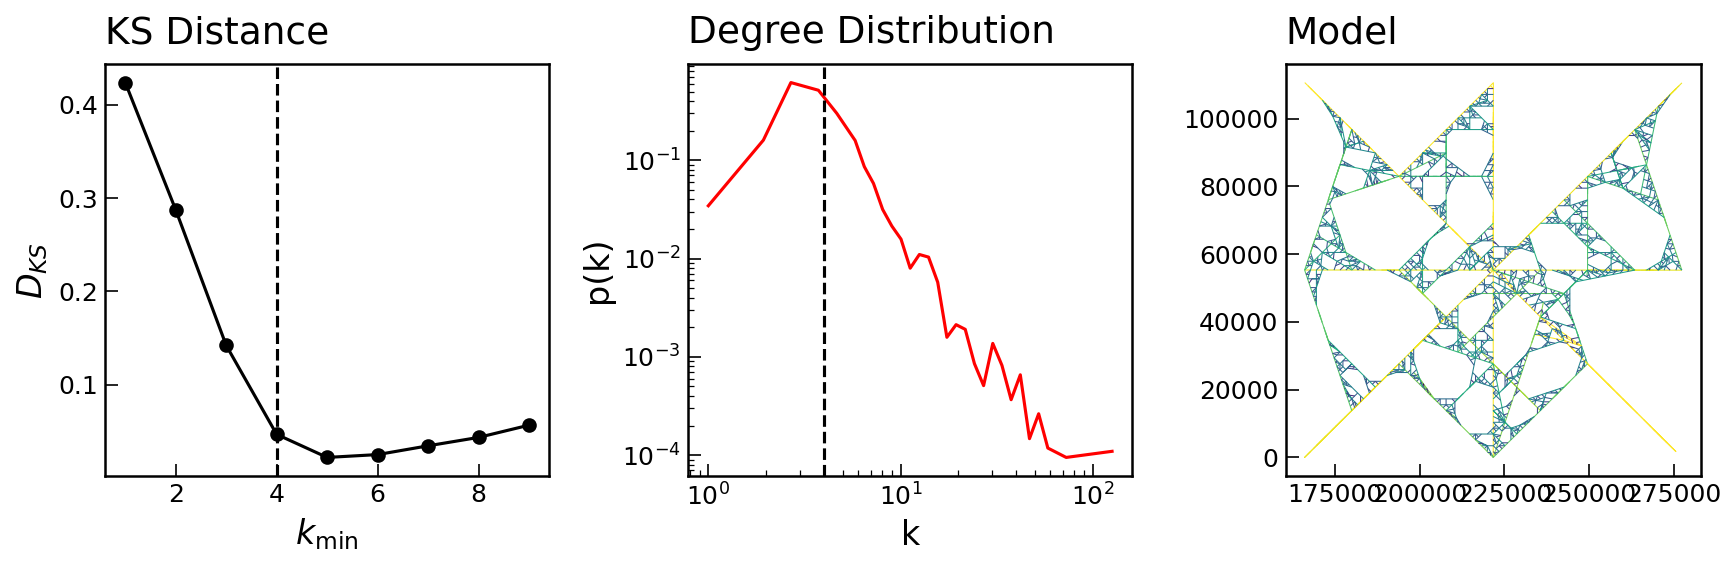

Knee point: 4


In [106]:
model1 = get_geodataframe(model=1, min_length=0.02)
model1['osmid'] = model1.index
G = momepy.gdf_to_nx(model1, approach='primal')
gdf_merged1, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=10, data=G, enforce_degree2=False, simplify_roundabout=False)
cool_plot(gdf_merged1)

# model 2

  Model 2: converged at iteration 2816 with 5703 segments


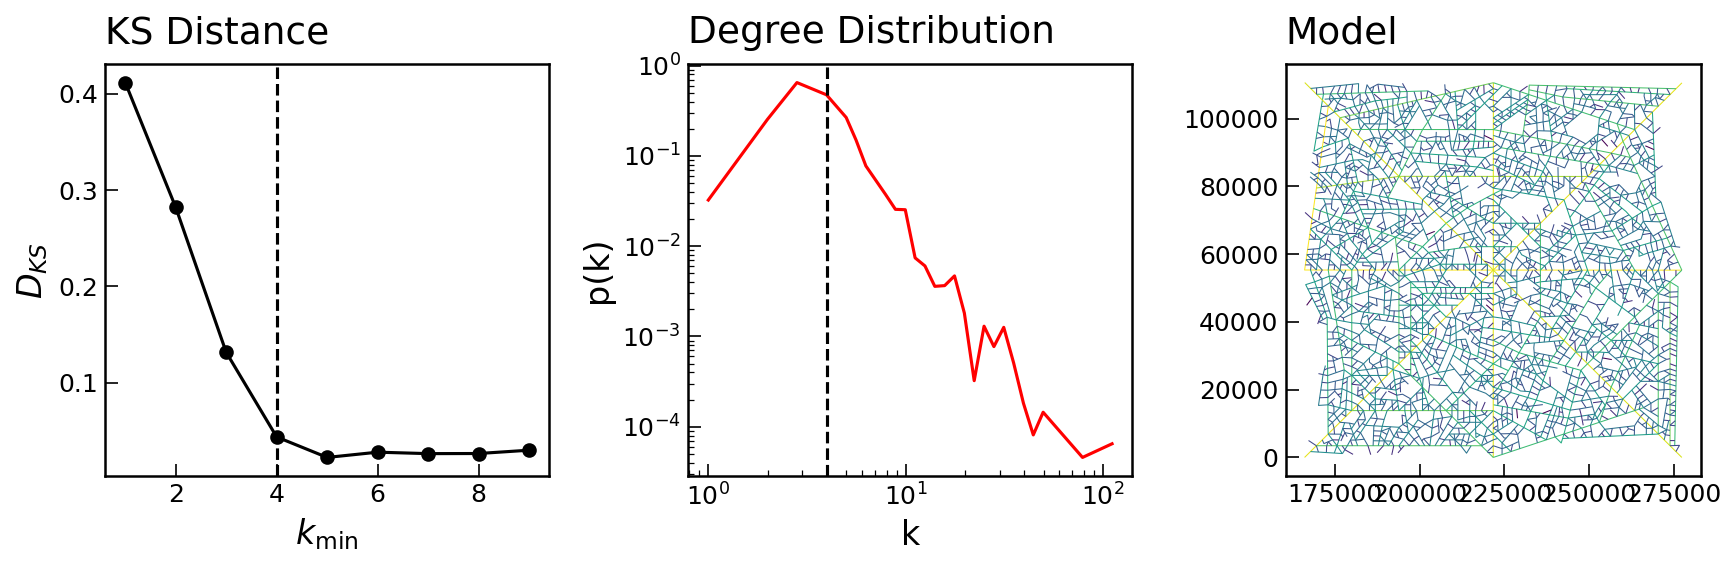

Knee point: 4


In [107]:
model2 = get_geodataframe(model=2, 
                          area_coeff=0.,
                          min_length=0.025, 
                          p_stub=1,
                          stub_len_max=0.025,
                          snap_tol=0,
                          seed=1,
                          noise_frac=0,
                          select = 'length')

                        #   seed=4,
                        #   min_angle=np.pi/6,
                        #   max_angle=np.pi/2,

model2['osmid'] = model2.index
G = momepy.gdf_to_nx(model2, approach='primal')
gdf_merged2, _, _, _ = get_dual_dir_con(t_buffer=1, a_threshold=10, data=G, enforce_degree2=False, simplify_roundabout=False)
cool_plot(gdf_merged2)

# probability weights

  Model 2: converged at iteration 639 with 1232 segments
  Model 2: converged at iteration 511 with 1030 segments
  Model 2: converged at iteration 666 with 1276 segments


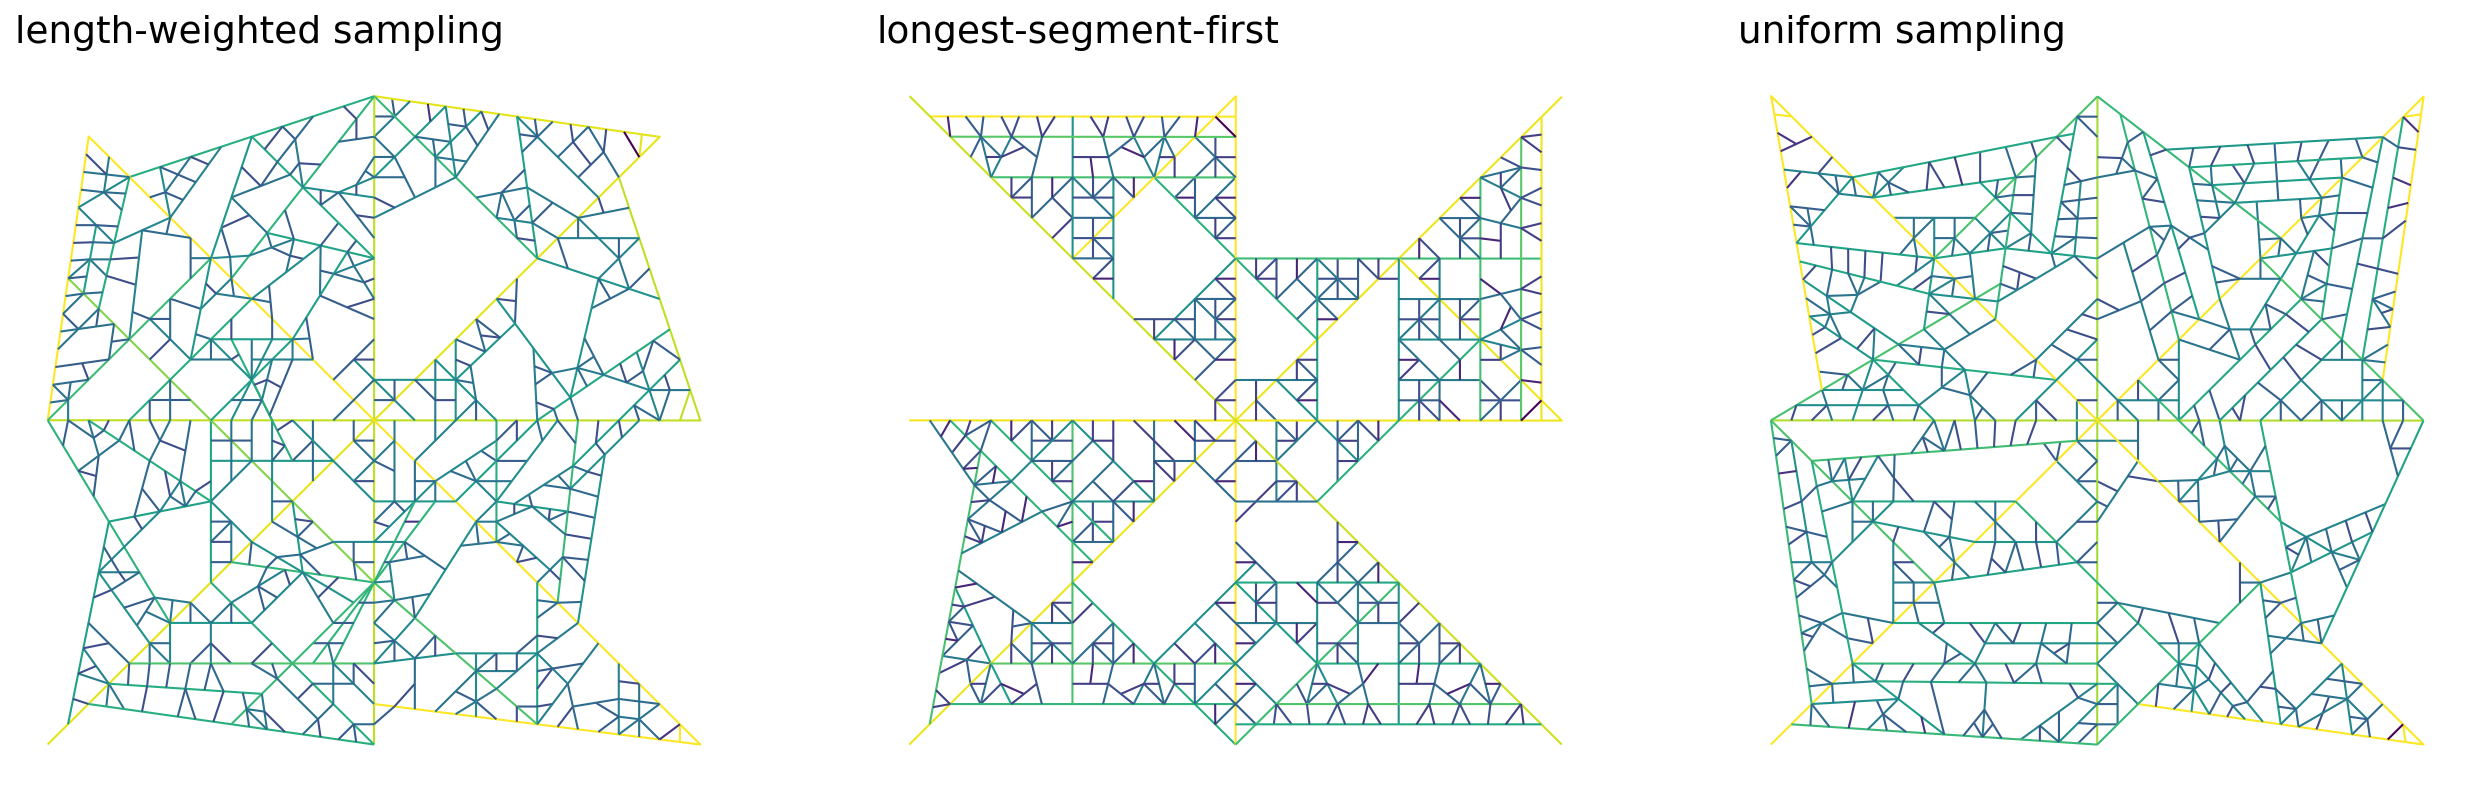

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
axes = axes.ravel()


model2 = get_geodataframe(model=2, area_coeff=0., min_length=0.05,seed=4,min_angle=np.pi/6,max_angle=np.pi/2,select = 'length')
model2['osmid'] = model2.index
G = momepy.gdf_to_nx(model2, approach='primal')
gdf_merged2, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=2, data=G, enforce_degree2=False, simplify_roundabout=False)
ax3 = axes[0]
gdf_merged2.plot(ax=ax3, column='degree_log', linewidth=1)
ax3.set_aspect('equal')
ax3.axis('off')

model2 = get_geodataframe(model=2, area_coeff=0., min_length=0.05,seed=4,min_angle=np.pi/6,max_angle=np.pi/2,select = 'longest')
model2['osmid'] = model2.index
G = momepy.gdf_to_nx(model2, approach='primal')
gdf_merged2, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=2, data=G, enforce_degree2=False, simplify_roundabout=False)
ax3 = axes[1]
gdf_merged2.plot(ax=ax3, column='degree_log', linewidth=1)
ax3.set_aspect('equal')
ax3.axis('off')


model2 = get_geodataframe(model=2, area_coeff=0., min_length=0.05,seed=4,min_angle=np.pi/6,max_angle=np.pi/2,select = 'uniform')
model2['osmid'] = model2.index
G = momepy.gdf_to_nx(model2, approach='primal')
gdf_merged2, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=2, data=G, enforce_degree2=False, simplify_roundabout=False)
ax3 = axes[2]
gdf_merged2.plot(ax=ax3, column='degree_log', linewidth=1)
ax3.set_aspect('equal')
ax3.axis('off')


axes[0].set_title('length-weighted sampling', loc='left')
axes[1].set_title('longest-segment-first', loc='left')
axes[2].set_title('uniform sampling', loc='left')


plt.show()

# ensemble

In [287]:
def process_seg(seg):
    model = to_geodataframe(seg, model_id=2)
    model['osmid'] = model.index
    G = momepy.gdf_to_nx(model, approach='primal')
    gdf_merged, _, _, _ = get_dual_dir_con(
        t_buffer=10, a_threshold=10, data=G,
        enforce_degree2=False, simplify_roundabout=False
    )
    return gdf_merged.degree.values.tolist()


seeds  = random.sample(range(1, 1001), 100) 

segs = run_ensemble(model=2, 
                    area_coeff=0.,
                    min_length=0.05, 
                    p_stub=0.2,
                    stub_len_max=0.001,
                    snap_tol=0.01,
                    # noise
                    seeds=seeds,
                    noise_frac=0.04,
                    noise_snap_tol=0.002,
                    noise_branch_prob=0.6,
                    noise_len_max=0.025,
                    select = 'length') 
                    
# area_coeff=0., min_length=0.05, p_stub=0.2, stub_len_max=0.001, snap_tol=0.01
# noise_frac=0.04, noise_len_max=0.025, snap_tol=0.002, branch_prob=0.6

n_workers = len(seeds)+1
with Pool(processes=n_workers) as pool:
    results = list(tqdm(pool.imap(process_seg, segs), total=len(segs)))

d_full = [d for sublist in results for d in sublist]

100%|██████████| 100/100 [00:04<00:00, 24.79it/s]


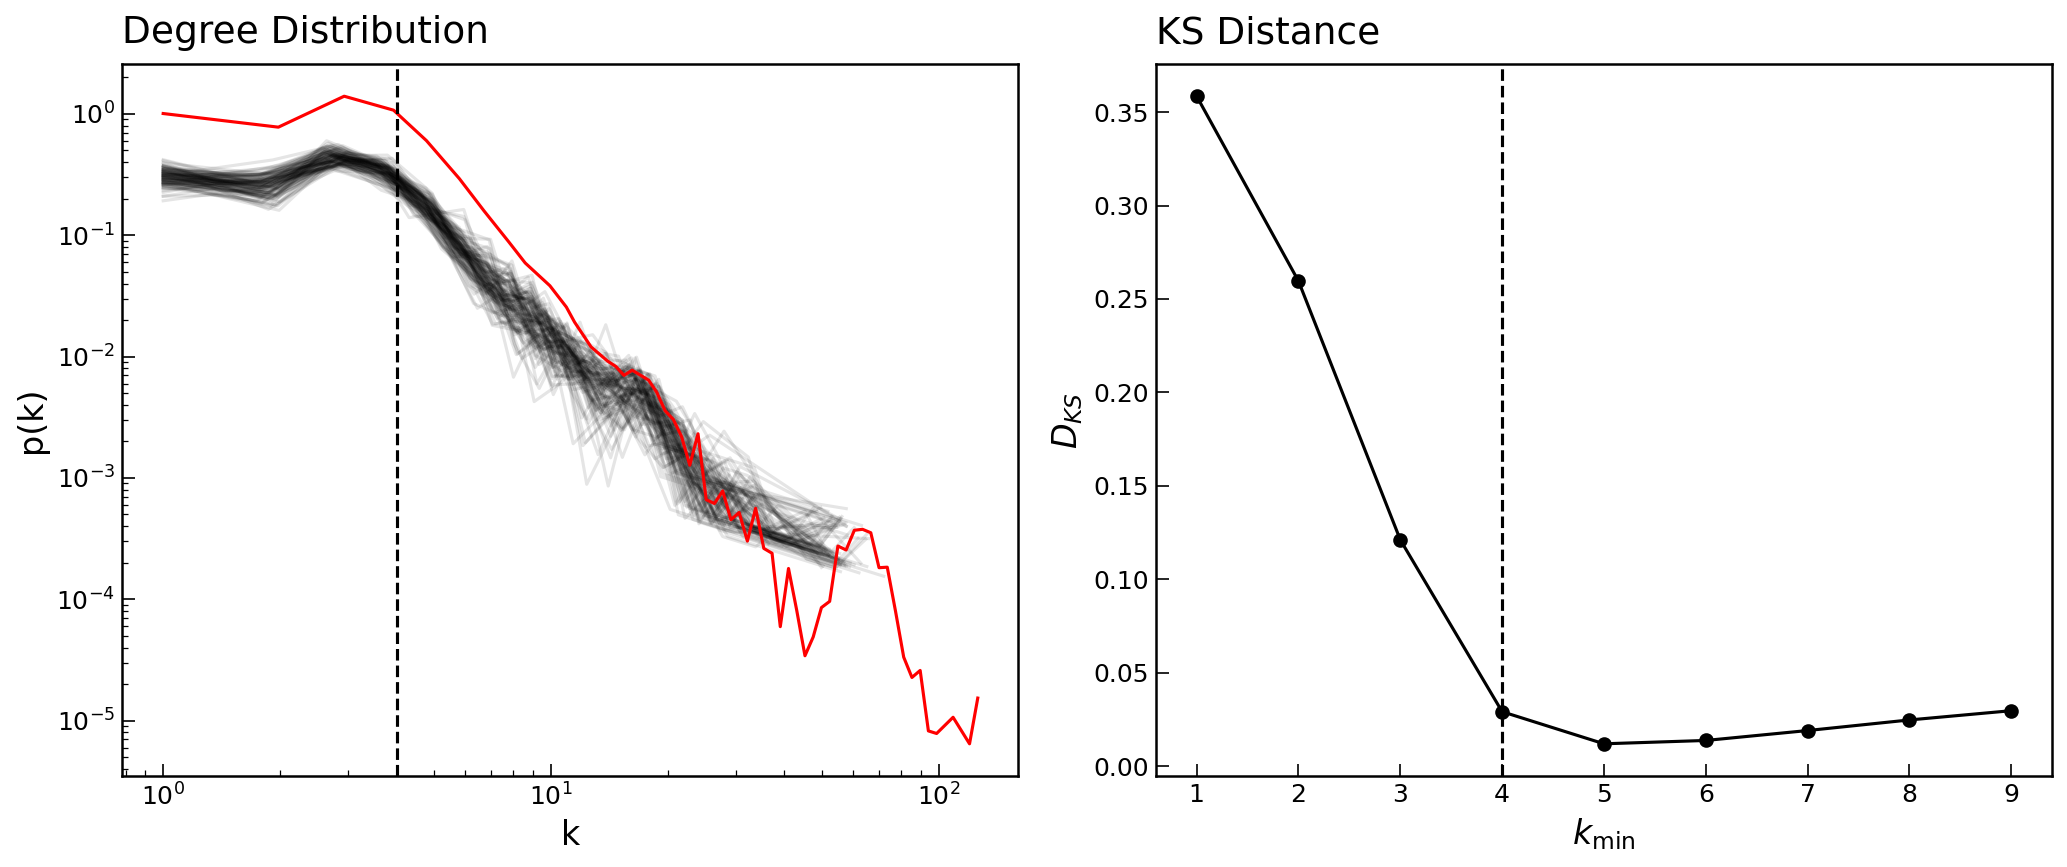

Knee point: 4


In [288]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


ax = axes[0]
for deg in results:
    y, x = np.histogram(np.array(deg), bins=np.logspace(0, np.log10(np.array(deg).max()), len(np.unique(np.array(deg)))), density=True)
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax.plot(x_nn, y_nn, alpha=.1, zorder=2, color='k')

# full
y, x = np.histogram(np.array(d_full), bins=np.logspace(0, np.log10(np.array(d_full).max()), len(np.unique(np.array(d_full)))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='red')


ax.set_ylabel('p(k)')
ax.set_xlabel('k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("Degree Distribution", loc='left')
ax.axvline(x=4, color='k', linestyle='--', label=r'$\phi$')
# ax.axvline(x=1, color='blue', linestyle='--', label=r'$\phi$')
# ax.axvline(x=2, color='blue', linestyle='--', label=r'$\phi$')
# ax.axvline(x=3, color='blue', linestyle='--', label=r'$\phi$')

# ---- KS DIST ----
ax1 = axes[1]
d = np.array(d_full)
d=d[d != 0]
ks_dist1, xmins1, _ = compute_ks(d, range(1,10))

ax1.scatter(xmins1,ks_dist1,color='k')
ax1.plot(xmins1,ks_dist1,color='k')
ax1.set_xlabel(r'$k_{\min}$')
ax1.set_ylabel(r'$D_{KS}$')
ax1.set_title('KS Distance', loc='left')
ax1.axvline(x=4, color='k', linestyle='--', label=r'$\phi$')

plt.tight_layout()
plt.show()

kn = KneeLocator(xmins1,ks_dist1, curve='convex', direction='decreasing')
print("Knee point:", kn.knee)

# Space fill with noise

  Model 2: converged at iteration 642 with 1247 segments


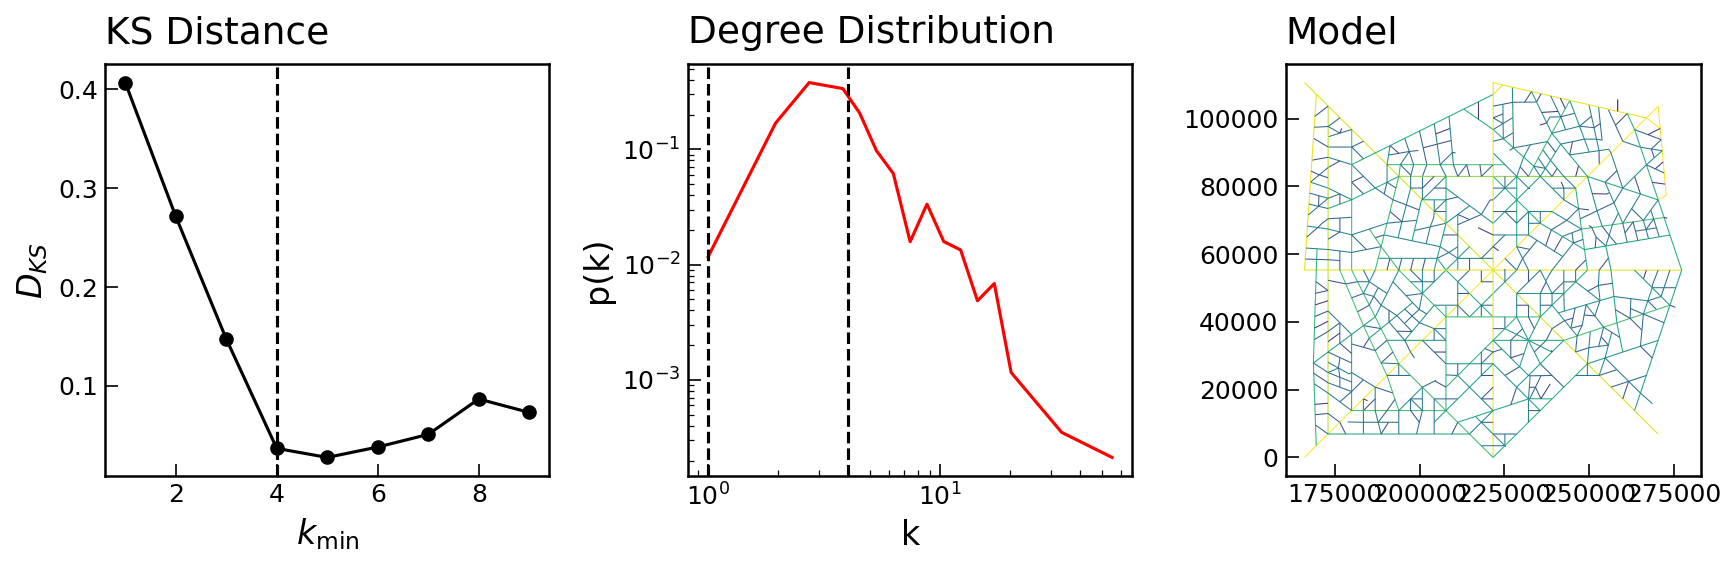

Knee point: 4


In [264]:
# 1) grow once, no noise
segs = run_model(model=2, area_coeff=0., min_length=0.05, p_stub=0.2, stub_len_max=0.001, snap_tol=0.01,select='length',seed=234)
gdf_clean = to_geodataframe(segs, model_id=2)
gdf_clean['osmid'] = gdf_clean.index
G = momepy.gdf_to_nx(gdf_clean, approach='primal')
gdf_merged, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=10, data=G, enforce_degree2=False, simplify_roundabout=False)
cool_plot(gdf_merged)

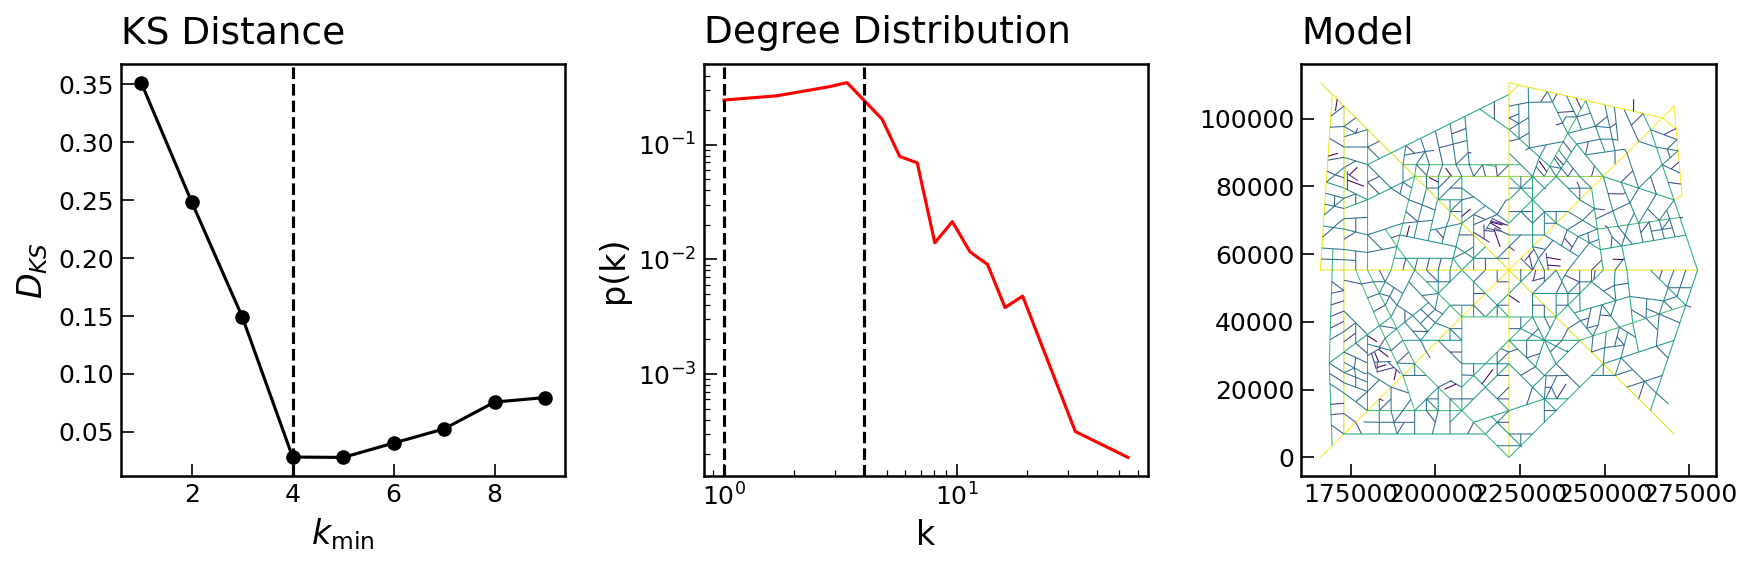

Knee point: 4


In [273]:
noisy = add_noise_streets(segs,  
                          noise_frac=0.04, 
                          seed=32, 
                        #   min_length=0.001, 
                          noise_len_max=0.025,
                          snap_tol=0.002, 
                          branch_prob=0.6)

gdf_noisy = to_geodataframe(noisy, model_id=2)



gdf_noisy['osmid'] = gdf_noisy.index
G = momepy.gdf_to_nx(gdf_noisy, approach='primal')
gdf_merged, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=10, data=G, enforce_degree2=False, simplify_roundabout=False)
cool_plot(gdf_merged)

In [88]:
gdf_noisy['osmid'] = gdf_noisy.index
G = momepy.gdf_to_nx(gdf_noisy, approach='primal')
gdf_merged1, _, _, _ = get_dual_dir_con(t_buffer=10, a_threshold=10, data=G, enforce_degree2=False, simplify_roundabout=False)

# GIF

In [110]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from pathlib import Path

frames = []
tmp_dir = Path("/home/lpsha/s154446/fractality/space_filling_model/plots/GIF/")
tmp_dir.mkdir(exist_ok=True)

for i in range(615):
    model1 = get_geodataframe(
        model=2,
        min_length=0.05,
        max_iter=i,
        seed=1,
        verbose=False
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    model1.plot(ax=ax)

    frame_path = tmp_dir / f"frame_{i:03d}.png"
    plt.savefig(frame_path, bbox_inches="tight")
    plt.close(fig)

    frames.append(imageio.imread(frame_path))

imageio.mimsave("animation.gif", frames, duration=0.5, loop=0)  # 0.5 sec/frame

In [109]:
model1 = get_geodataframe(
    model=2,
    min_length=0.05,
    area_coeff=0.,
    max_iter=1000000,
    seed=1,
    verbose=True
)

  Model 2: converged at iteration 615 with 1133 segments


In [112]:
# from IPython.display import Image
# Image(filename="animation.gif")